# H4. Связь цены заказа с оценкой покупателя

## 1. Постановка задачи

### Бизнес-вопрос

Связана ли стоимость товаров в заказе с оценкой, которую покупатель оставляет после получения заказа?

### Нулевая гипотеза H0

Между стоимостью заказа и оценкой покупателя отсутствует статистически значимая монотонная связь:

rho_s = 0

### Альтернативная гипотеза H1

Между стоимостью заказа и оценкой покупателя существует статистически значимая монотонная связь:

rho_s < 0

### Метод

Для проверки гипотезы используется коэффициент ранговой корреляции Спирмена, поскольку:

- `order_price` является количественным признаком;
- `review_score` является порядковым признаком со значениями от 1 до 5;
- распределение стоимости заказов может быть асимметричным и содержать выбросы;
- метод не требует нормального распределения;
- проверяется наличие монотонной, а не обязательно линейной связи.

Уровень значимости:

alpha = 0.05

### Единица анализа

Оценка (`review_score`) относится ко всему заказу, поэтому цена также рассчитывается на уровне заказа:

order_price = sum i_price

где i_price — стоимость отдельной позиции заказа.

Стоимость доставки (`freight_value`) в `order_price` не включается, чтобы анализировать именно стоимость товаров.


## 2. Подготовка окружения

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv

In [3]:
_ = load_dotenv()

In [4]:
DB_USERNAME = os.getenv("DB_USERNAME")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USERNAME,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

In [5]:
engine = create_engine(url=url)

## 3. Получение данных

Для анализа используются доставленные заказы, для которых известны:

- стоимость хотя бы одной позиции заказа;
- оценка покупателя.

Так как один заказ может содержать несколько товаров, сначала позиции агрегируются до уровня `order_id`.

Если для одного `order_id` существует несколько отзывов, используется **самый новый отзыв по `review_creation_date`**.


In [6]:
read_sql_query = """
WITH latest_reviews AS (
    SELECT
        review_id,
        order_id,
        review_score,
        review_creation_date,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY
                review_creation_date DESC NULLS LAST
        ) AS rn
    FROM order_reviews
    WHERE review_score IS NOT NULL
),

order_prices AS (
    SELECT
        order_id,
        COUNT(*) AS item_count,
        SUM(price) AS order_price
    FROM order_items
    WHERE price IS NOT NULL
    GROUP BY order_id
)

SELECT
    o.order_id,
    r.review_id,
    p.item_count,
    p.order_price,
    r.review_score
FROM orders AS o
JOIN order_prices AS p
    ON o.order_id = p.order_id
JOIN latest_reviews AS r
    ON o.order_id = r.order_id
    AND r.rn = 1
WHERE
    o.order_status = 'delivered';
"""

df = pd.read_sql(
    sql=read_sql_query,
    con=engine,
)

## 4. Проверка качества данных

Перед статистическим анализом проверим:

- размер выборки;
- уникальность `order_id`;
- отсутствие пропущенных значений;
- отсутствие отрицательной или нулевой стоимости заказа;
- допустимый диапазон оценок от 1 до 5;
- корректность количества позиций заказа.


In [7]:
df.head()

,order_id,review_id,item_count,order_price,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,97ca439bc427b48bc1cd7177abe71365,1,58.90,5
1,00018f77f2f0320c557190d7a144bdd3,7b07bacd811c4117b742569b04ce3580,1,239.90,4
2,000229ec398224ef6ca0657da4fc703e,0c5b33dea94867d1ac402749e5438e8b,1,199.00,5
3,00024acbcdf0a6daa1e931b038114c75,f4028d019cb58564807486a6aaf33817,1,12.99,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,940144190dcba6351888cafa43f3a3a5,1,199.90,5


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      95832 non-null  str    
 1   review_id     95832 non-null  str    
 2   item_count    95832 non-null  int64  
 3   order_price   95832 non-null  float64
 4   review_score  95832 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.7 MB


In [9]:
quality_checks = pd.Series({
    "rows": len(df),
    "unique_orders": df["order_id"].nunique(),
    "duplicate_orders": df["order_id"].duplicated().sum(),
    "missing_values": df.isna().sum().sum(),
    "non_positive_order_price": (df["order_price"] <= 0).sum(),
    "invalid_item_count": (df["item_count"] <= 0).sum(),
    "invalid_review_scores": (~df["review_score"].between(1, 5)).sum(),
})

quality_checks

rows                        95832
unique_orders               95832
duplicate_orders                0
missing_values                  0
non_positive_order_price        0
invalid_item_count              0
invalid_review_scores           0
dtype: int64

In [10]:
df[["order_price", "item_count", "review_score"]].describe().round(2)

,order_price,item_count,review_score
count,95832.00,95832.00,95832.00
mean,136.80,1.14,4.16
std,207.78,0.53,1.28
min,0.85,1.00,1.00
25%,45.90,1.00,4.00
50%,86.25,1.00,5.00
75%,149.90,1.00,5.00
max,13440.00,21.00,5.00


## 5. Описательный анализ

Сначала рассмотрим распределения стоимости заказов и оценок, затем сравним стоимость заказов между группами `review_score`.


### 5.1. Распределение оценок


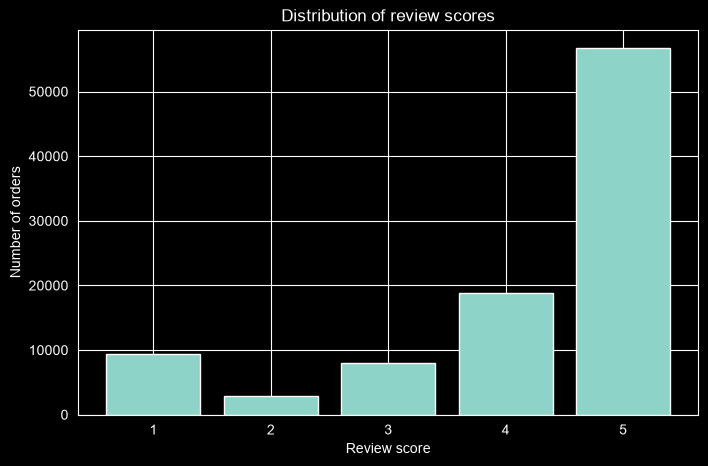

In [11]:
review_distribution = (
    df["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution.index,
    review_distribution.values,
)

plt.title("Distribution of review scores")
plt.xlabel("Review score")
plt.ylabel("Number of orders")
plt.xticks(range(1, 6))

plt.show()

### 5.2. Распределение стоимости заказов

Распределение стоимости анализируется на исходных данных. Для отдельного графика также ограничим ось значением 99-го перцентиля — только для визуализации центральной части распределения. Из статистического анализа дорогие заказы не удаляются.


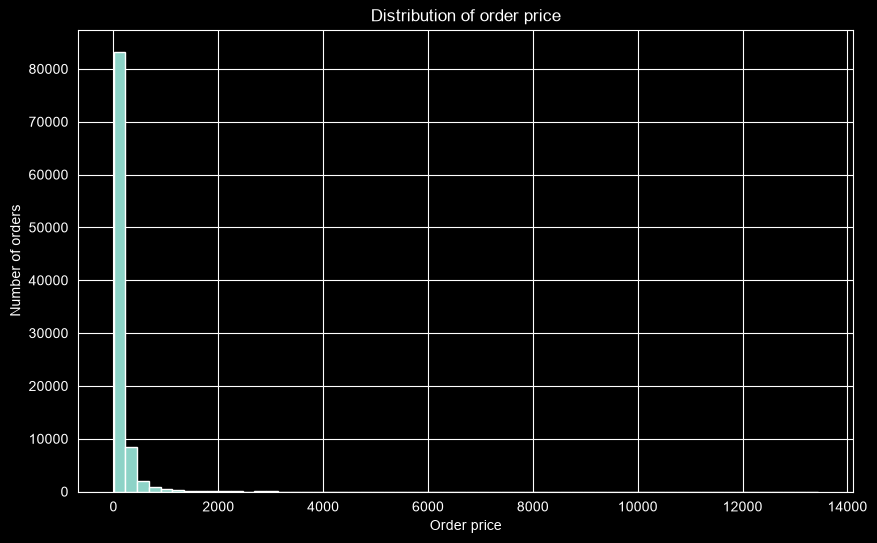

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["order_price"],
    bins=60,
)

plt.title("Distribution of order price")
plt.xlabel("Order price")
plt.ylabel("Number of orders")

plt.show()

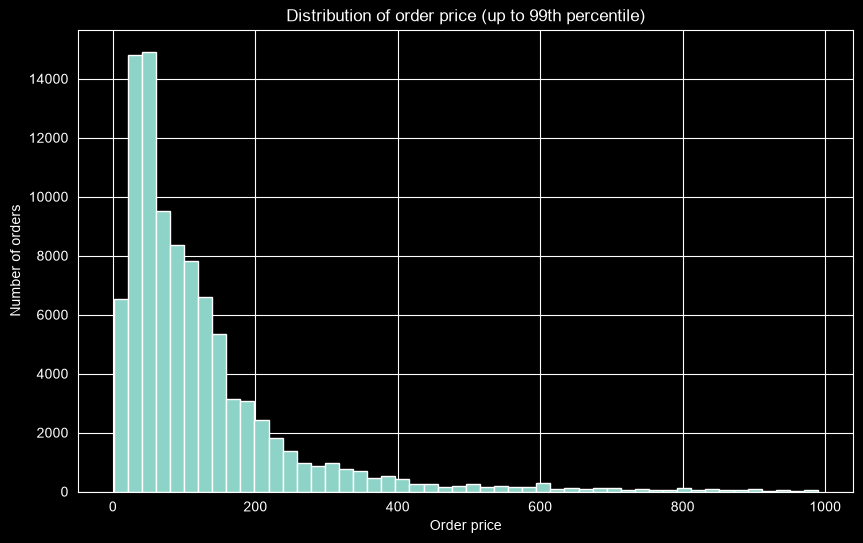

99th percentile: 990.00


In [13]:
price_p99 = df["order_price"].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df["order_price"] <= price_p99, "order_price"],
    bins=50,
)

plt.title("Distribution of order price (up to 99th percentile)")
plt.xlabel("Order price")
plt.ylabel("Number of orders")

plt.show()

print(f"99th percentile: {price_p99:.2f}")

### 5.3. Стоимость заказа в зависимости от оценки

Сравним распределения `order_price` между оценками от 1 до 5.

Выбросы на boxplot скрываются только визуально через `showfliers=False`; исходные наблюдения остаются в статистическом анализе.


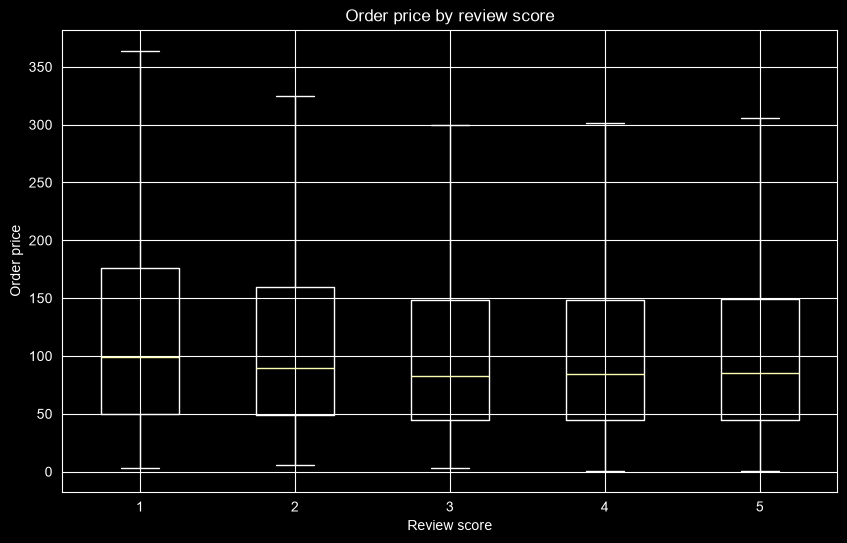

In [14]:
price_by_review = [
    df.loc[
        df["review_score"] == score,
        "order_price",
    ].to_numpy()
    for score in range(1, 6)
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    price_by_review,
    tick_labels=range(1, 6),
    showfliers=False,
)

plt.title("Order price by review score")
plt.xlabel("Review score")
plt.ylabel("Order price")

plt.show()

### 5.4. Описательная статистика по оценкам

Рассчитаем размер групп, среднее, медиану, стандартное отклонение и квартили стоимости заказа для каждого значения `review_score`.


In [15]:
price_stats = (
    df.groupby("review_score")["order_price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .round(2)
)

price_stats

,count,mean,median,std,q25,q75
review_score,,,,,,
1,9353,164.98,99.00,287.54,50.0,175.99
2,2920,143.71,89.90,215.76,49.0,159.90
3,7918,127.49,82.99,167.62,44.9,148.52
4,18894,132.28,84.00,194.80,45.0,148.00
5,56747,134.61,84.99,200.45,45.0,149.65


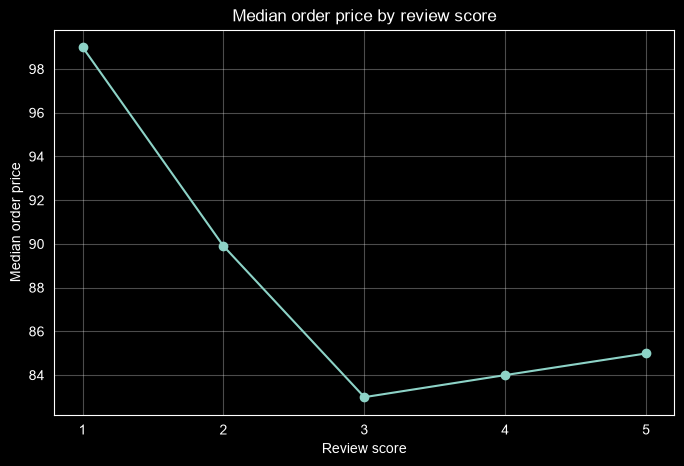

In [16]:
median_price = (
    df.groupby("review_score")["order_price"]
    .median()
)

plt.figure(figsize=(8, 5))

plt.plot(
    median_price.index,
    median_price.values,
    marker="o",
)

plt.title("Median order price by review score")
plt.xlabel("Review score")
plt.ylabel("Median order price")
plt.xticks(range(1, 6))
plt.grid(alpha=0.3)

plt.show()

## 6. Проверка статистической гипотезы

Для оценки монотонной связи между стоимостью заказа и оценкой покупателя используется коэффициент корреляции Спирмена.

Поскольку альтернативная гипотеза не задаёт направление связи, применяется **двусторонний** тест.

Критерий принятия решения:

- если (p < 0.05), нулевая гипотеза отвергается;
- если (p >= 0.05), оснований для отклонения нулевой гипотезы недостаточно.

Сам коэффициент rho_s одновременно показывает направление и силу монотонной связи.


In [17]:
ALPHA = 0.05

spearman_result = stats.spearmanr(
    df["order_price"],
    df["review_score"],
    alternative="two-sided",
)

rho = spearman_result.statistic
p_value = spearman_result.pvalue

print(f"Spearman rho: {rho:.4f}")

if p_value < 0.001:
    print("p-value: < 0.001")
else:
    print(f"p-value: {p_value:.4f}")

if p_value < ALPHA:
    print("Reject H0")
    print(
        "There is evidence of a statistically significant "
        "monotonic relationship between order price and review score."
    )
else:
    print("Fail to reject H0")
    print(
        "There is insufficient evidence of a statistically significant "
        "monotonic relationship between order price and review score."
    )

Spearman rho: -0.0290
p-value: < 0.001
Reject H0
There is evidence of a statistically significant monotonic relationship between order price and review score.


## 7. Оценка неопределённости

Помимо точечной оценки rho_s, рассчитаем 95% bootstrap-доверительный интервал.

Доверительный интервал помогает оценить не только статистическую значимость, но и диапазон правдоподобных значений силы связи.

In [18]:
def bootstrap_spearman_ci(
    x,
    y,
    n_iterations=2000,
    confidence_level=0.95,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x)
    correlations = np.empty(n_iterations)

    for i in range(n_iterations):
        indices = rng.integers(
            0,
            n,
            size=n,
        )

        correlations[i] = stats.spearmanr(
            x[indices],
            y[indices],
        ).statistic

    alpha = 1 - confidence_level

    lower = np.quantile(
        correlations,
        alpha / 2,
    )

    upper = np.quantile(
        correlations,
        1 - alpha / 2,
    )

    return lower, upper

In [19]:
ci_lower, ci_upper = bootstrap_spearman_ci(
    df["order_price"],
    df["review_score"],
)

print(
    f"95% CI: "
    f"[{ci_lower:.4f}, {ci_upper:.4f}]"
)

95% CI: [-0.0356, -0.0224]


## 8. Интерпретация размера эффекта

Для корреляции Спирмена абсолютное значение коэффициента можно использовать как характеристику силы монотонной связи.

**Условная** ориентировочная шкала:

- `|rho| < 0.10` — очень слабая связь;
- `0.10 <= |rho| < 0.30` — слабая;
- `0.30 <= |rho| < 0.50` — умеренная;
- `|rho| >= 0.50` — сильная.

Эти границы являются ориентировочными: практическая значимость всегда должна интерпретироваться в контексте бизнес-задачи.


In [20]:
def interpret_correlation(rho):
    abs_rho = abs(rho)

    if abs_rho < 0.10:
        return "very weak"
    if abs_rho < 0.30:
        return "weak"
    if abs_rho < 0.50:
        return "moderate"
    return "strong"


effect_strength = interpret_correlation(rho)

if rho > 0:
    direction = "positive"
elif rho < 0:
    direction = "negative"
else:
    direction = "no"

print(f"Direction: {direction}")
print(f"Effect strength: {effect_strength}")

Direction: negative
Effect strength: very weak


## 9. Итоговая таблица

In [21]:
results = pd.DataFrame({
    "metric": [
        "Spearman rho",
        "p-value",
        "CI lower",
        "CI upper",
        "sample size",
        "alpha",
    ],
    "value": [
        rho,
        p_value,
        ci_lower,
        ci_upper,
        len(df),
        ALPHA,
    ],
})

results

,metric,value
0,Spearman rho,-2.895131e-02
1,p-value,3.127006e-19
2,CI lower,-3.563593e-02
3,CI upper,-2.237587e-02
4,sample size,9.583200e+04
5,alpha,5.000000e-02


## 10. Результаты и вывод

Итог гипотезы следует интерпретировать по трём уровням:

1. **Статистическая значимость** — позволяет решить, есть ли основания отвергнуть H0.
2. **Направление связи** — определяется знаком коэффициента Спирмена.
3. **Размер эффекта** — определяется абсолютным значением rho_s и его доверительным интервалом.

Важно: даже при очень маленьком `p-value` связь может быть практически слабой, особенно при большой выборке.

Также корреляция не доказывает причинно-следственную связь. На оценку заказа одновременно могут влиять качество товара, доставка, продавец, категория товара, ожидания клиента и другие факторы.


In [22]:
print("Statistical conclusion")
print("-" * 60)

print(f"Spearman rho: {rho:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Effect strength: {effect_strength}")

if p_value < 0.001:
    print("p-value: < 0.001")
else:
    print(f"p-value: {p_value:.4f}")

print()

if p_value < ALPHA:
    print(
        "H0 is rejected: order price and review score "
        "have a statistically significant monotonic relationship."
    )
else:
    print(
        "H0 is not rejected: there is insufficient evidence "
        "of a monotonic relationship between order price "
        "and review score."
    )

print()
print("Business interpretation")

if p_value < ALPHA:
    print(
        f"The relationship is {direction} and {effect_strength}. "
        "Its practical importance should be evaluated using "
        "the magnitude of Spearman rho and the confidence interval, "
        "not p-value alone."
    )
else:
    print(
        "The analysis does not provide sufficient statistical evidence "
        "that order price is associated with customer review score."
    )

print()
print(
    "This analysis identifies an association and does not establish "
    "that changing the order price causes a change in review score."
)

Statistical conclusion
------------------------------------------------------------
Spearman rho: -0.0290
95% CI: [-0.0356, -0.0224]
Effect strength: very weak
p-value: < 0.001

H0 is rejected: order price and review score have a statistically significant monotonic relationship.

Business interpretation
The relationship is negative and very weak. Its practical importance should be evaluated using the magnitude of Spearman rho and the confidence interval, not p-value alone.

This analysis identifies an association and does not establish that changing the order price causes a change in review score.
